# Gender Pay Gap Analysis: Descriptive Insights Across Job Roles

## Third Notebook: Investigating Adjusted Disparities and Actionable Insights

This notebook builds on the insights from the first two notebooks, which provided a detailed descriptive overview and formal statistical assessment of compensation patterns across job titles, departments, education levels, performance evaluation, and more.  

The goal of this third notebook is to **investigate compensation disparities and provide actionable insights**. Using the findings from previous analyses and conducting additional investigations where necessary, we aim to answer the central research question and identify areas for organizational action.  

The overarching research question remains:  

**To what extent does gender influence compensation levels across comparable job titles and professional characteristics?** 

Through careful analysis and clear visualizations, this notebook will:  

1. Provide a thorough answer to the research question.
2. Highlight roles where gender disparities persist.  
3. Provide insights that can directly inform **HR policies, pay equity interventions, and strategic decision-making**.  

Author: J-F Jutras  
Date: January 2026  
Dataset: Gender Pay Gap — Glassdoor (Kaggle)

## 2.1-Data Loading

In [1]:
import pandas as pd
import os
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("nilimajauhari/glassdoor-analyze-gender-pay-gap")

#Define dataset path
dataset_dir = "/kaggle/input/glassdoor-analyze-gender-pay-gap"
csv_path = os.path.join(dataset_dir, "Glassdoor Gender Pay Gap.csv")

#Load full dataset
df = pd.read_csv(csv_path)

### Column Description

| Column Name | Description                                   |
|------------|-----------------------------------------------|
| JobTitle   | Job title / role                              |
| Gender     | Gender                                       |
| Age        | Age in years                                 |
| PerfEval   | Performance evaluation score (from 1 to 5)                |
| Education  | Level of education                           |
| Dept       | Department                                   |
| Seniority  | Seniority (from 1 to  5)           |
| BasePay    | Annual base pay in USD                       |
| Bonus      | Annual bonus pay in USD                     |


In [2]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 1677, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 1677 (delta 115), reused 31 (delta 31), pack-reused 1523 (from 3)
Receiving objects: 100% (1677/1677), 567.62 KiB | 5.97 MiB/s, done.
Resolving deltas: 100% (1055/1055), done.


## 2.2-Is There Evidence of a Gender Pay Gap? Going beyond intuition

When looking at BasePay and Bonus by job title, it intuitively appears that men are favored in some roles while women earn more in others. Regarding bonuses, women seem to receive slightly higher amounts on average. These observations are preliminary and descriptive, providing an initial sense of patterns without drawing definitive conclusions about pay equity.

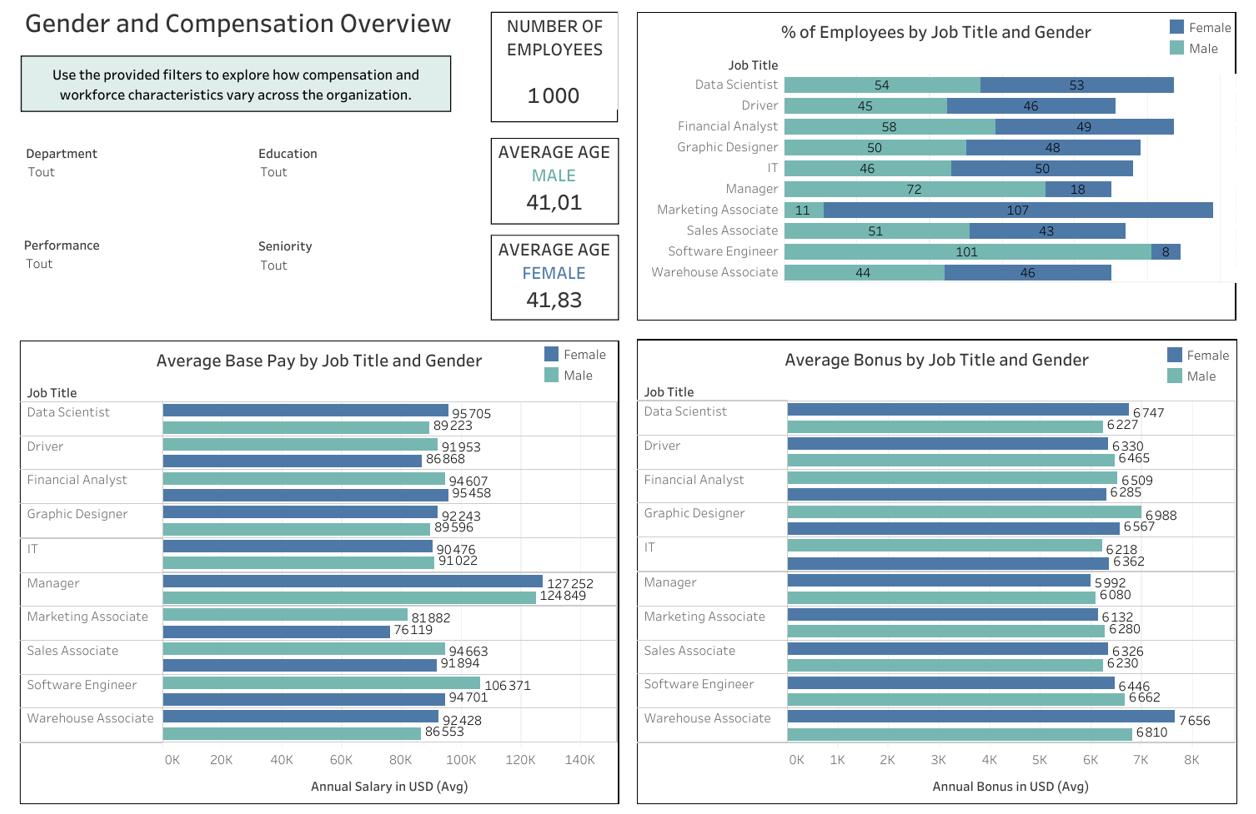
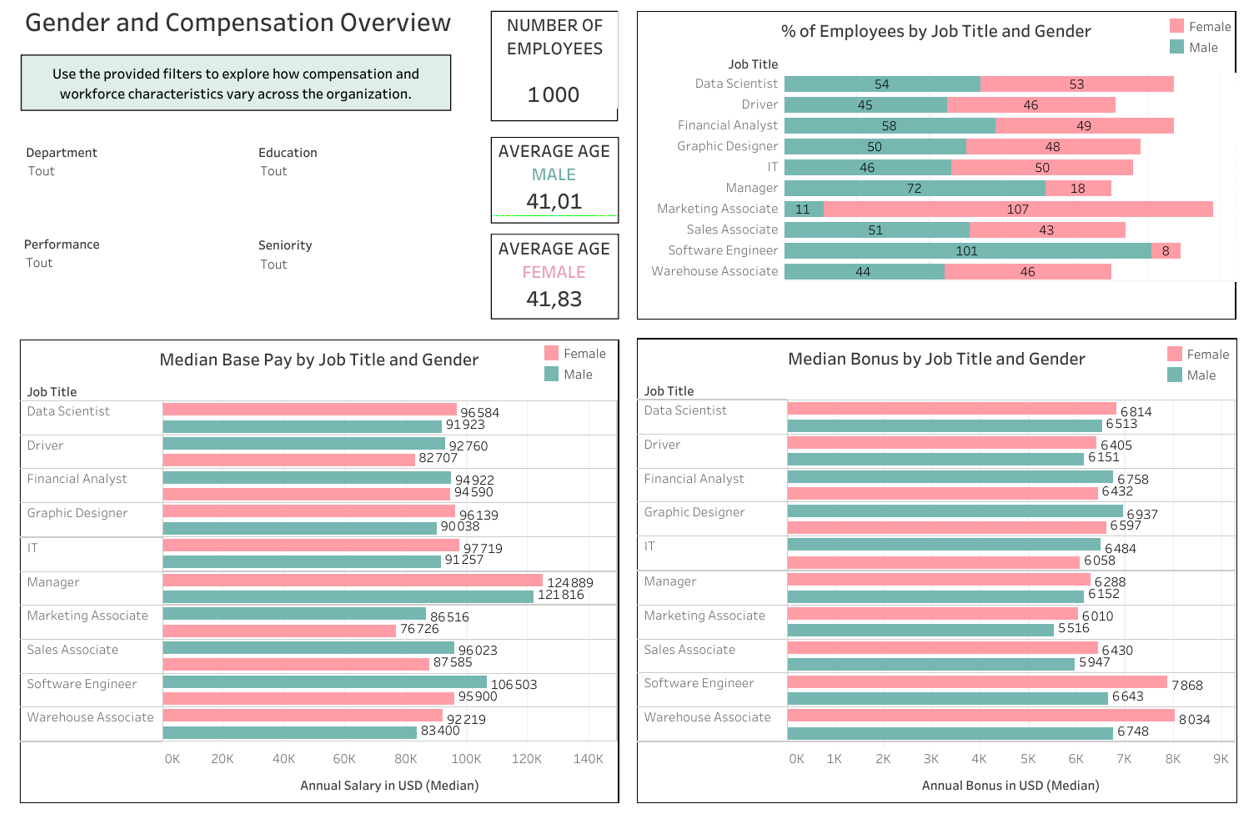

**Dashboard View**

-  Job title composition shows clear gender imbalances (e.g., Managers & Software Engineers → mostly men; Marketing Associates → mostly women)

-  Median base pay is generally higher in male-dominated roles, with some exceptions

-  Median bonuses seem to slightly favor women in some roles

**Taking the analysis a step further**

While these descriptive dashboards may suggest the presence of gender-based compensation differences, visual inspection alone is insufficient to determine whether such disparities persist once professional characteristics are taken into account.

To move beyond descriptive impressions, multivariate linear regression (MLR) models were conducted to simultaneously control for key professional and organizational factors influencing compensation. These include job title, department, education, seniority, age, and performance-related variables.

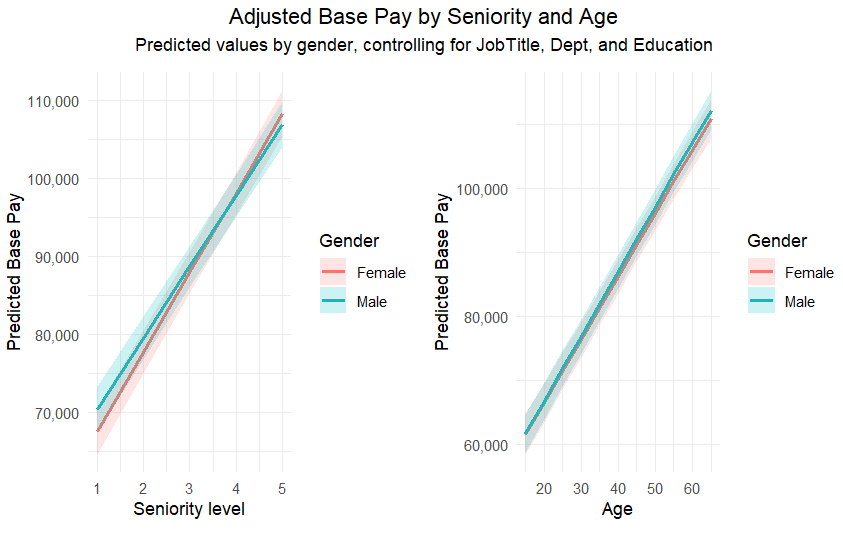

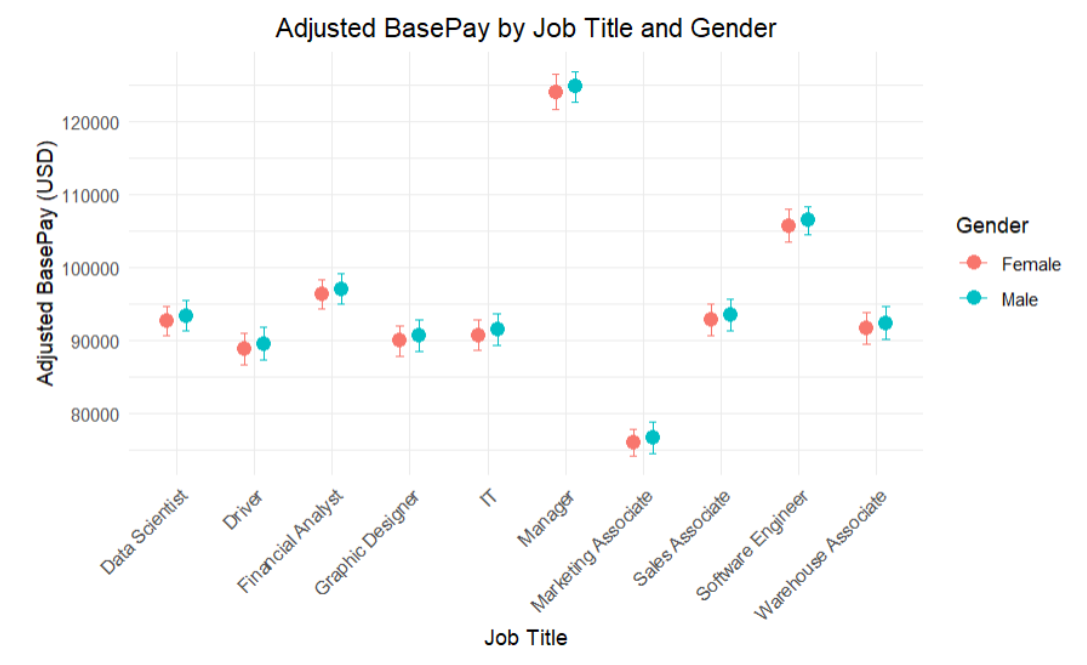

**BasePay** shows no statistically meaningful association with gender after adjustment.

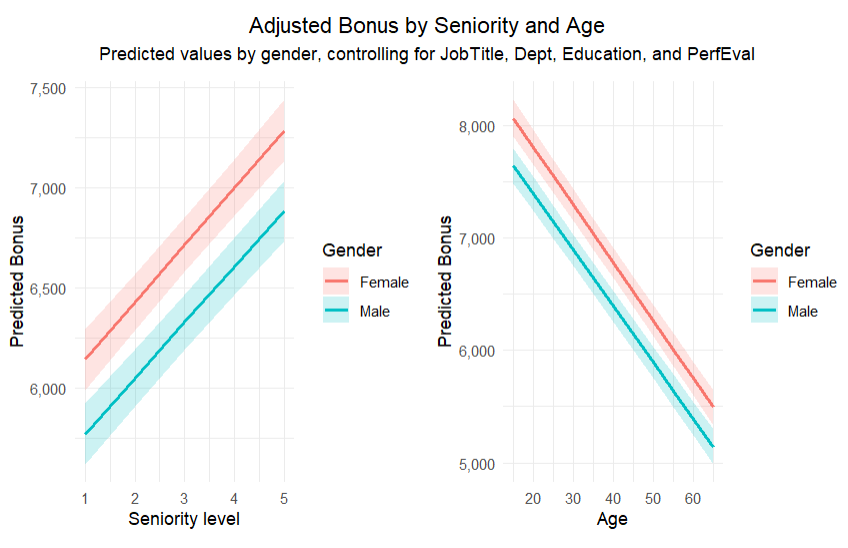

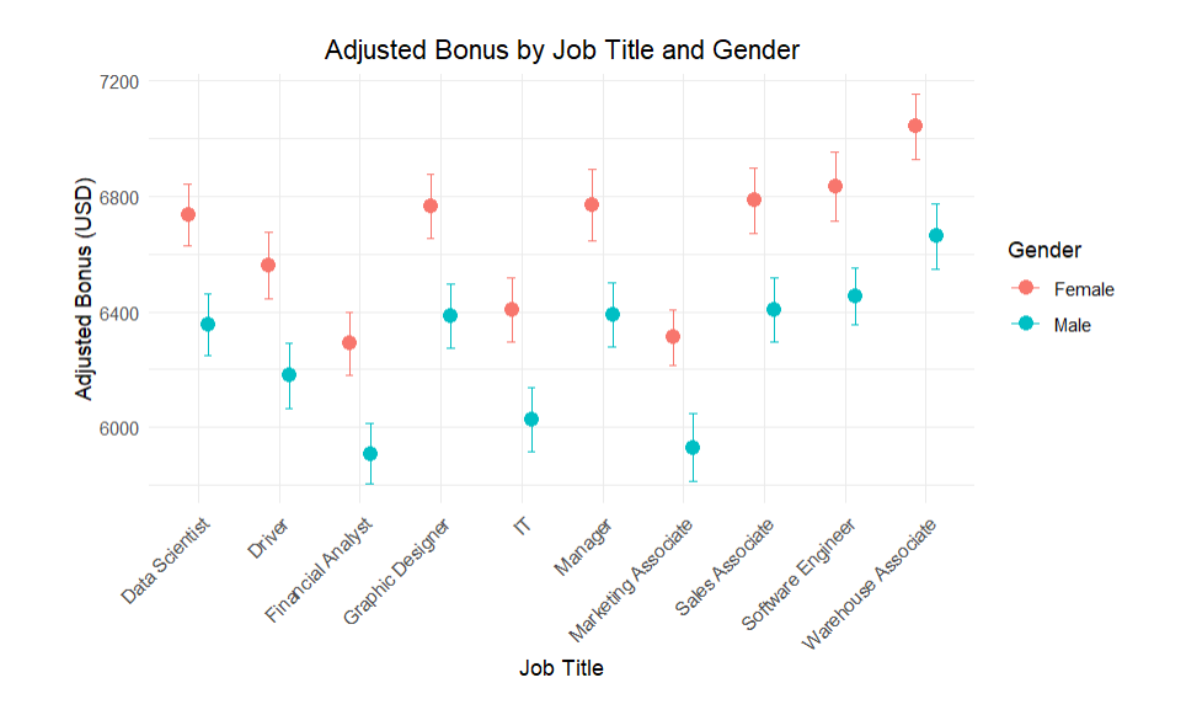
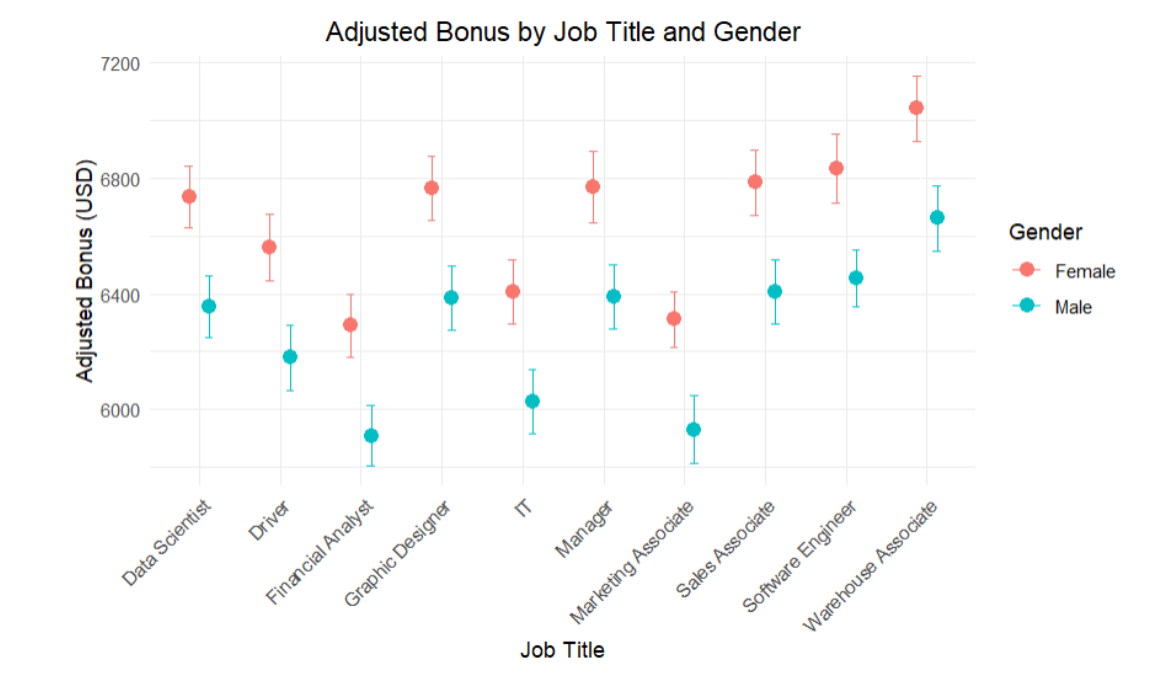

**Bonus** outcomes similarly do not indicate a disadvantage for women; if anything, adjusted results suggest a slightly lower bonus level for men, though the magnitude of this difference remains limited.

After accounting for professional and organizational characteristics, neither BasePay nor Bonus show a systematic disadvantage for women. Adjusted analyses suggest that apparent differences observed in the raw dashboards largely reflect job, department, seniority, and performance factors rather than gender alone. 

**Considering the organization as a whole only, these results provide no evidence of a consistent gender pay gap.**

## 2.3-Trying to Understand the Perceived Gender Pay Gap

Substantial gender imbalances exist within departments across specific job titles, a phenomenon known as **occupational segregation**. These imbalances can give the appearance of a gender pay gap in raw, descriptive statistics, even if pay within roles is equitable.

To formally assess these imbalances, a Chi-square test of independence will be conducted between gender and job title.

In [3]:
from eda.chi_square_test import chi_square_test
chi_square_test(df, 'Gender', 'JobTitle', show_table = True)

Contingency Table: Gender vs JobTitle
JobTitle  Data Scientist  Driver  Financial Analyst  Graphic Designer  IT  \
Gender                                                                      
Female                53      46                 49                48  50   
Male                  54      45                 58                50  46   

JobTitle  Manager  Marketing Associate  Sales Associate  Software Engineer  \
Gender                                                                       
Female         18                  107               43                  8   
Male           72                   11               51                101   

JobTitle  Warehouse Associate  
Gender                         
Female                     46  
Male                       44  

Chi-square test for Gender vs JobTitle:
Chi2 = 188.24, p-value = 0.0000, dof = 9
Cramér's V = 0.434


The contingency table shows clear gender imbalances across job titles. While roles like Data Scientist, Driver, Financial Analyst, Graphic Designer, IT, and Warehouse Associate have relatively balanced gender representation, Manager, Marketing Associate, and Software Engineer roles exhibit pronounced gender skew: most managers and software engineers are men, while marketing associates are predominantly women.

The chi-square test confirms that these differences are statistically significant (Chi² = 188.24, p < 0.001), and the Cramér’s V of 0.434 indicates a moderate to strong association between gender and job title.

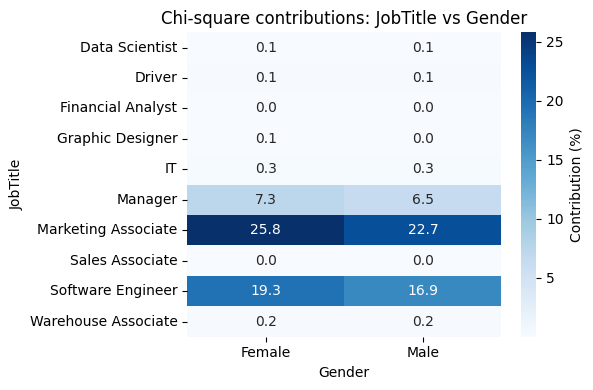

In [4]:
from visualization.chi_square_heatmap import chi_square_heatmap
chi_square_heatmap(df, 'JobTitle', 'Gender', figsize = (6,4), cmap = "Blues")

It is important to note that the three job categories driving the largest gender imbalances—Manager, Marketing Associate, and Software Engineer—likely have very different employment profiles and responsibilities. These differences should be carefully reviewed internally to understand the context behind the observed segregation.

Nevertheless, it is worth exploring whether specific factors or interventions could help reduce gender disparities within these roles, even if structural or role-based differences exist. This sets the stage for investigating actionable insights to promote more equitable compensation and opportunities.

**Comparative Profile of Selected Job Titles by Gender**

| JobTitle            | Gender | Age_mean | Age_median | Seniority_mean | Seniority_median | PerfEval_mean | PerfEval_median | BasePay_mean | BasePay_median | Bonus_mean | Bonus_median | High School | College | Masters | PhD |
|--------------------|--------|----------|------------|----------------|-----------------|---------------|----------------|--------------|----------------|------------|--------------|-------------|--------|---------|-----|
| Manager             | Female | 44.61    | 45.0       | 3.00           | 3.0             | 2.39          | 2.0            | 127252.28    | 124889.0      | 5992.00    | 6287.5       | 8           | 0      | 5       | 5   |
| Manager             | Male   | 42.01    | 43.0       | 2.89           | 3.0             | 2.78          | 3.0            | 124848.93    | 121815.5      | 6080.22    | 6151.5       | 12          | 23     | 16      | 21  |
| Marketing Associate | Female | 42.12    | 42.0       | 3.00           | 3.0             | 2.90          | 3.0            | 76119.18     | 76726.0       | 6131.97    | 6010.0       | 36          | 24     | 24      | 23  |
| Marketing Associate | Male   | 37.09    | 40.0       | 3.45           | 4.0             | 3.18          | 3.0            | 81881.82     | 86516.0       | 6279.82    | 5516.0       | 2           | 3      | 2       | 4   |
| Software Engineer   | Female | 37.00    | 32.0       | 2.38           | 2.0             | 2.75          | 3.0            | 94701.00     | 95900.0       | 6446.38    | 7868.0       | 2           | 2      | 1       | 3   |
| Software Engineer   | Male   | 41.18    | 39.0       | 2.97           | 3.0             | 3.16          | 3.0            | 106371.49    | 106503.0      | 6662.33    | 6643.0       | 30          | 17     | 31      | 23  |


**Manager**: Female managers are slightly older with comparable seniority to males but hold fewer advanced degrees. Despite this, their average base pay is slightly higher than males, suggesting relative pay parity after accounting for professional characteristics.

**Marketing Associate**: Women dominate this role numerically and are slightly older, with similar performance scores. Male associates, though fewer, have higher average pay, indicating potential effects of experience or selection on compensation.

**Software Engineer**: Men are the majority and slightly more senior; women earn lower average base pay despite occasionally higher bonuses. The slightly higher proportion of Masters and PhDs among men may partly explain these differences.

We will keep these role-specific insights in mind as we move to the Actionable Insights section, where targeted interventions can be explored to reduce remaining gender disparities.

## 2.4-What About Bonus Attribution?

In our previous analyses, we observed that, at the company level, women tend to receive slightly higher bonuses than men on average. To understand whether this pattern persists when controlling for role and seniority, we will examine whether performance evaluations are comparable across genders.

Rather than stratifying by individual job titles, we will group employees by department and seniority, since performance evaluations are generally conducted at the department level rather than by specific job titles. This approach better reflects organizational practices and allows us to compare men and women in equivalent professional contexts. We will validate this assumption by checking the distribution of genders within each department × seniority stratum before performing statistical comparisons.

In [5]:
#Group the data by Department, Seniority, and Gender, counting the number of employees in each group
strat_table = (
    df.groupby(['Dept', 'Seniority', 'Gender'], observed=True)
      .size()  
      .unstack(fill_value = 0)  
      .sort_index(level=['Dept', 'Seniority']) 
)

#Display the stratified table
strat_table

Gender                    Female  Male
Dept           Seniority              
Administration 1              19    19
               2              20    16
               3              15    17
               4              19    23
               5              22    23
Engineering    1              16    17
               2              24    15
               3              16    19
               4              13    25
               5              20    27
Management     1              14    22
               2              17    22
               3              22    29
               4              20    18
               5              14    20
Operations     1              18    27
               2              23    25
               3              26    29
               4              12    20
               5              17    13
Sales          1              16    27
               2              18    29
               3              27    19
               4              16    18
               5              24    13

Gender distribution varies across departments and seniority levels. Some strata, like senior levels in Engineering and lower levels in Sales and Operations, show more balanced gender representation, while others exhibit noticeable imbalances favoring either males or females.

We use the non-parametric Mann–Whitney U test to compare performance evaluations between males and females at equal seniority within each department, as PerfEval is discrete and ordinal. All assumptions for the test (independence of observations, ordinal scale, and reasonably similar distribution shapes) are satisfied. Since multiple comparisons are performed across departments and seniority levels, we apply the FDR correction to control for false discoveries.

In [6]:
# Import packages
!{sys.executable} -m pip install -q pingouin scikit-posthocs scikit-bio
from eda.stats_non_param import mann_whitney_cliff
from statsmodels.stats.multitest import multipletests

results_list = []
raw_pvalues = [] 

#Loop over each Department and Seniority
for dept in df['Dept'].unique():
    for level in sorted(df['Seniority'].unique()):
        stratum_df = df[(df['Dept'] == dept) & (df['Seniority'] == level)]
        
        #Check if both genders are present
        if stratum_df['Gender'].nunique() == 2:
            #Run Mann-Whitney test and store raw p-value
            res = mann_whitney_cliff(
                stratum_df,
                value_col='PerfEval',
                group_col='Gender',
                group1='Male',
                group2='Female',
                alternative='two-sided'
            )
            raw_pvalues.append(res['p_value'])
            
            #Keep department and seniority info
            res['Dept'] = dept
            res['Seniority'] = level
            results_list.append(res)

#Combine all results into a DataFrame
mw_results = pd.DataFrame(results_list)

#Apply FDR (Benjamini-Hochberg) correction
_, p_adj, _, _ = multipletests(mw_results['p_value'], method='fdr_bh')
mw_results['p_value_adj'] = p_adj

#Reorder columns
mw_results = mw_results[['Dept', 'Seniority', 'Group 1', 'Group 2', 'n_group1', 'n_group2',
                         'U_statistic', 'p_value', 'p_value_adj', 'Cliffs_delta']]

#Display results
mw_results

,Dept,Seniority,Group 1,Group 2,n_group1,n_group2,U_statistic,p_value,p_value_adj,Cliffs_delta
0,Operations,1,Male,Female,27,18,163.0,0.059628,0.496902,-0.329218
1,Operations,2,Male,Female,25,23,303.0,0.751382,0.984483,0.053913
2,Operations,3,Male,Female,29,26,393.5,0.782824,0.984483,0.043767
3,Operations,4,Male,Female,20,12,114.0,0.826781,0.984483,-0.050000
4,Operations,5,Male,Female,13,17,113.5,0.914160,0.984483,0.027149
5,Management,1,Male,Female,22,14,143.5,0.739213,0.984483,-0.068182
6,Management,2,Male,Female,22,17,212.5,0.466591,0.984483,0.136364
7,Management,3,Male,Female,29,22,317.5,0.984483,0.984483,-0.004702
8,Management,4,Male,Female,18,20,263.5,0.012375,0.309375,0.463889
9,Management,5,Male,Female,20,14,175.5,0.209726,0.873858,0.253571


**Raw results** 

Some strata show directional differences in performance evaluations: for example, in Management level 4, females have slightly higher scores than males (Cliff’s Delta = 0.464), and in Operations level 1, males score higher than females (Cliff’s Delta = -0.329). Most other strata show small or negligible differences between genders.

**Adjusted results**

After applying FDR correction for multiple comparisons, all differences become statistically non-significant. This means that, when accounting for multiple tests, there is no evidence of systematic gender differences in performance evaluations at equal seniority across departments.

These stratified performance insights, together with the adjusted statistical results, set the stage for the Actionable Insights section, where targeted measures can be considered to support equitable opportunities across the organization.

## 2.5-Can We Increase Workforce Homogeneity to Minimize Disparities?

It is important to emphasize that the analysis presented here is based solely on the available dataset and does not capture the full range of internal organizational information, such as budgets, financial benefits, detailed career paths, or internal HR policies. 

Therefore, while our recommendations are grounded in robust statistical observations and best practices for addressing gender disparities, they should be considered as preliminary action points to be evaluated and validated before implementation. 

A complementary analysis, taking into account the organization’s financial, operational, and strategic constraints, is necessary to assess the feasibility and actual impact of these initiatives.

| Axis / Area                  | Observed Imbalances / Issues | Potential Solutions |
|-------------------------------|----------------------------|-------------------|
| Occupational Segregation      | Strong gender imbalances across job titles within departments | 1. Implement targeted hiring programs to improve representation in underrepresented roles.<br>2. Encourage internal mobility across departments with structured transfer programs.<br>3. Introduce mentorship programs to support career growth in high-imbalance departments.<br>4. Review recruitment and promotion criteria to ensure transparency and fairness.<br>5. Conduct periodic audits to monitor role distribution by gender. |
| BasePay                       | No overall gender gap, but differences may exist if initial offers are unstandardized | 1. Develop a predictive salary offer tool for HR, factoring in education, seniority, department, and job title.<br>2. Standardize starting salary guidelines across roles.<br>3. Train HR and managers on consistent application of compensation frameworks.<br>4. Conduct scenario analyses to ensure offers do not inadvertently favor one group.<br>5. Regularly review market benchmarks to maintain fairness and competitiveness. |
| Bonus                         | Slightly significant lower bonuses for females despite similar performance evaluations | 1. Review and enhance objectivity of bonus calculation criteria.<br>2. Explore implementing a predictive bonus allocation tool based on performance metrics.<br>3. Train managers on consistent evaluation standards.<br>4. Ensure transparency in bonus determination process.<br>5. Monitor outcomes and adjust criteria to prevent unintentional disparities. |
| Education                     | Some departments have imbalanced representation in advanced degrees | 1. Offer incentives for pursuing advanced education in departments with low participation.<br>2. Establish learning and development programs accessible to all employees.<br>3. Create internal scholarships or support for professional certifications.<br>4. Encourage knowledge-sharing sessions for employees with advanced education.<br>5. Track participation and outcomes to ensure equitable access and impact. |
| Mentorship & Career Advancement | Limited access to leadership and growth opportunities for some groups | 1. Implement a manager mentorship program to improve access to leadership roles.<br>2. Evaluate employee interest before rolling out programs to ensure engagement.<br>3. Pair mentees with mentors outside their immediate department to expand exposure.<br>4. Incorporate development goals into performance reviews.<br>5. Monitor mentorship outcomes and career progression metrics. |
| Quality & Impact Monitoring   | Need to track effectiveness of implemented measures | 1. Define clear KPIs such as promotion rates, salary alignment, and internal mobility metrics.<br>2. Conduct regular review meetings at departmental and executive levels.<br>3. Establish an internal audit schedule to validate process adherence.<br>4. Create dashboards to monitor trends over time.<br>5. Adjust interventions based on observed outcomes and feedback. |

*It is essential to communicate this approach transparently at the executive level. While the company is committed to improving workplace practices, the analyses show that there is no systemic gender pay gap.* 

*Had decisions been based solely on raw data suggesting a gap, interventions could have inadvertently amplified disparities—favoring certain departments or incentive structures—without addressing the actual areas of imbalance observed. This measured and evidence-based approach ensures that initiatives target real opportunities for improvement without creating unintended inequities.*


## 2.6-Limitations

Limitation                                             | Explanation
------------------------------------------------------|---------------------------------------------------------------
Limited organizational data                            | Only Glassdoor dataset used; internal compensation policies, benefits, and adjustments not fully captured
External market factors                                | Regional pay benchmarks and market trends not included; may affect comparisons
Unobserved professional factors                        | Skills, certifications, informal responsibilities, and project impact not captured
Small job title group sizes                             | Limits statistical power for detailed role-level analysis
Incomplete bonus determinants                          | Discretionary or spot bonuses not fully represented; slight observed differences may be affected
Single-time snapshot                                   | Data reflects one point in time; cannot assess historical trends or career progression
Organizational context                                 | Culture, policies, and decision-making criteria not available; limits understanding of structural drivers
Potential residual confounding                          | Interactions between factors may still affect results despite multivariate adjustments
